In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("../data/creditcard.csv")

# Check dataset size
print("Dataset Shape:", df.shape)

# Show first few rows
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Check basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
# Check missing values
missing = df.isnull().sum()

print(missing)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [5]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 1081


In [6]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check new dataset size
print("New Shape:", df.shape)

New Shape: (283726, 31)


In [7]:
# Check fraud and normal transactions
print(df["Class"].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


In [8]:
# Check class percentage
class_percent = df["Class"].value_counts(normalize=True) * 100

print(class_percent)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


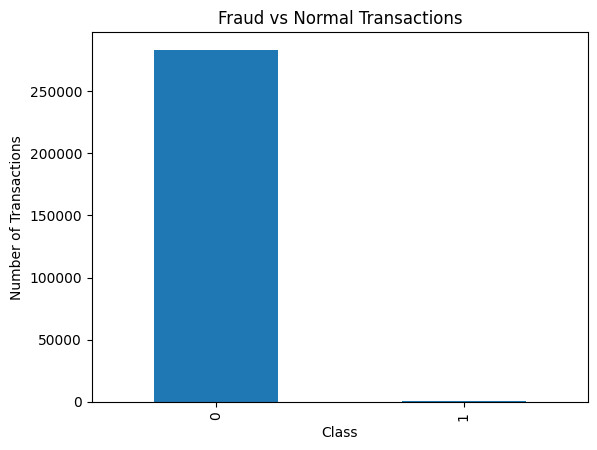

In [9]:
# Plot class distribution
df["Class"].value_counts().plot(kind="bar")

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

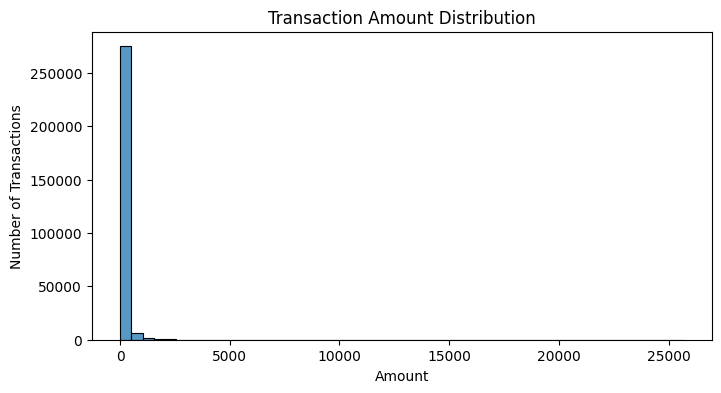

In [10]:
# Check transaction amount
plt.figure(figsize=(8, 4))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Number of Transactions")

plt.show()

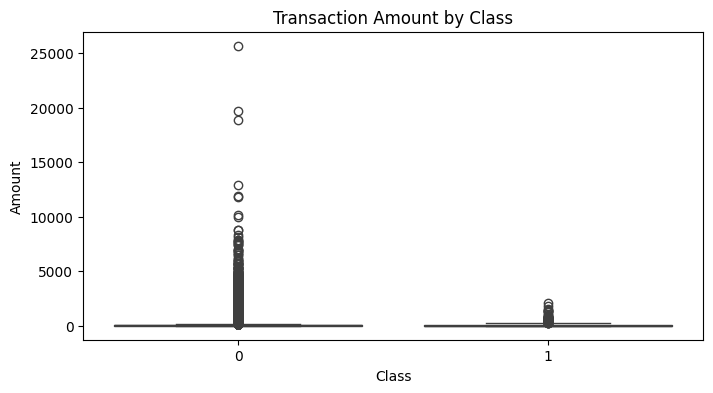

In [11]:
# Compare transaction amount by class
plt.figure(figsize=(8, 4))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

In [12]:
# Compare average transaction amount
avg_amount = df.groupby("Class")["Amount"].mean()

print(avg_amount)

Class
0     88.413575
1    123.871860
Name: Amount, dtype: float64


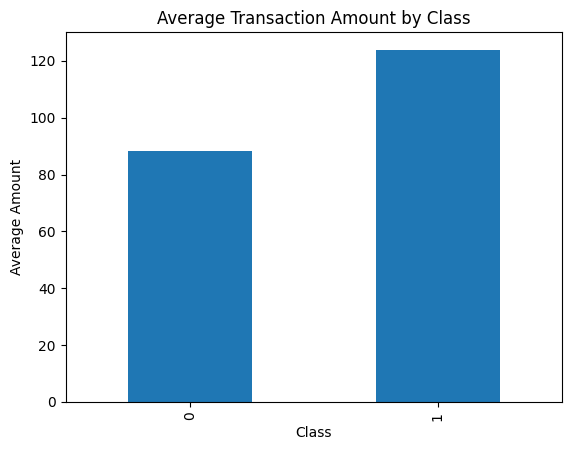

In [13]:
# Plot average amount by class
avg_amount.plot(kind="bar")

plt.title("Average Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Average Amount")

plt.show()

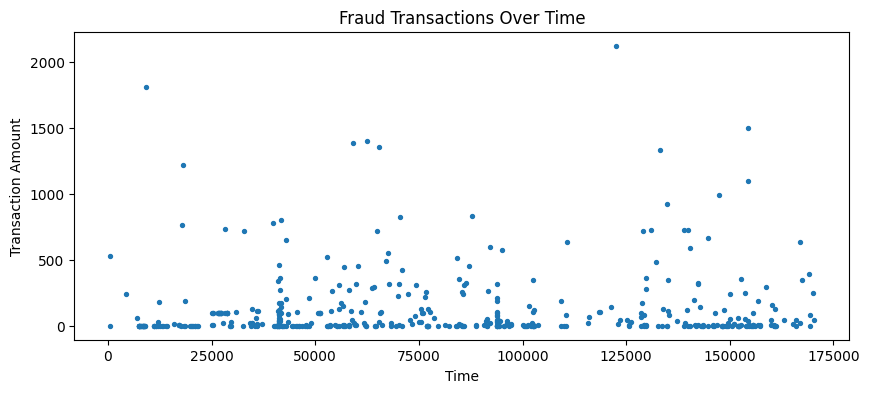

In [14]:
# Check fraud transactions over time
fraud_data = df[df["Class"] == 1]

plt.figure(figsize=(10, 4))

plt.scatter(fraud_data["Time"], fraud_data["Amount"], s=8)

plt.title("Fraud Transactions Over Time")
plt.xlabel("Time")
plt.ylabel("Transaction Amount")

plt.show()

In [15]:
# Check feature correlation with fraud class
correlation = df.corr()["Class"].sort_values(ascending=False)

print(correlation)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


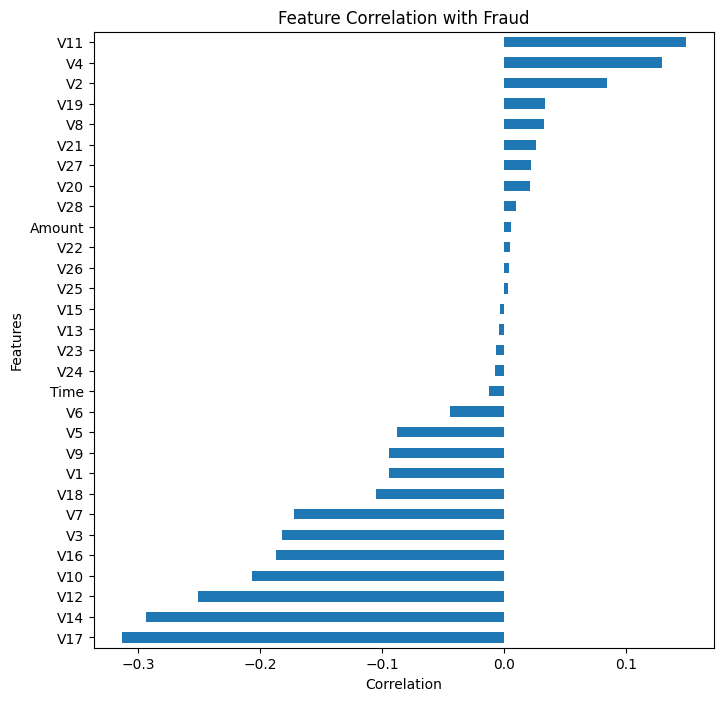

In [16]:
# Plot feature correlation with fraud
correlation.drop("Class").sort_values().plot(kind="barh", figsize=(8, 8))

plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

In [17]:
# Separate input features and target
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (283726, 30)
Target shape: (283726,)


In [18]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the split
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (226980, 30)
Testing data: (56746, 30)


In [19]:
# Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling to test data
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Scaling completed
Training shape: (226980, 30)
Testing shape: (56746, 30)


In [20]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train_scaled, y_train)

print("Model training completed")

Model training completed


In [21]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Get fraud probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Prediction completed")

Prediction completed


In [22]:
# Check model performance
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746



[[56649     2]
 [   28    67]]


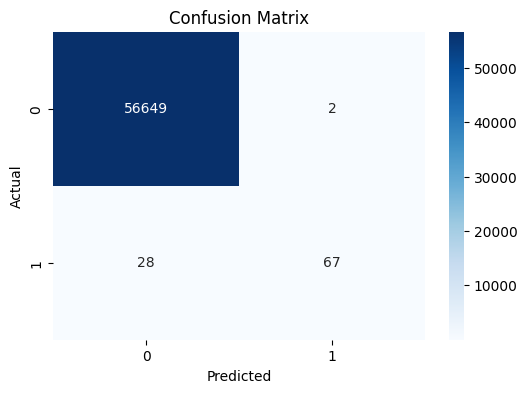

In [23]:
# Create confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
# Calculate PR-AUC
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", round(pr_auc, 4))

PR-AUC: 0.7958


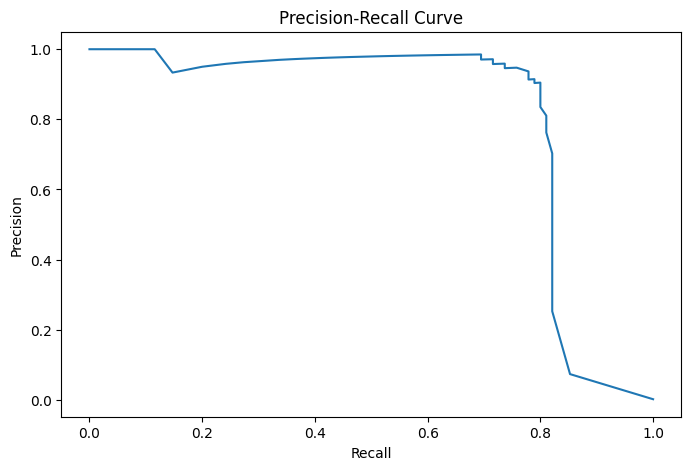

In [25]:
# Plot Precision-Recall curve
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))

plt.plot(recall, precision)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

In [26]:

# Calculate ROC-AUC
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.9246


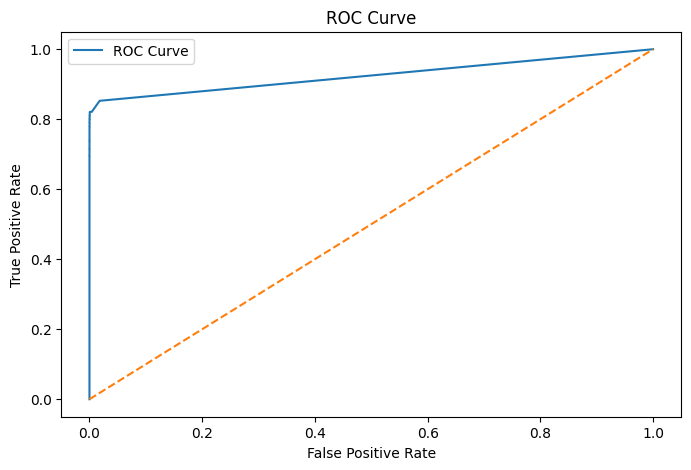

In [27]:
# Plot ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

In [28]:
# Save the trained model
import pickle
import os

os.makedirs("../models", exist_ok=True)

with open("../models/fraud_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully")

Model saved successfully


In [29]:
# Save the scaler
with open("../models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully")

Scaler saved successfully


In [30]:
# Save feature columns
feature_columns = X.columns.tolist()

with open("../models/feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file)

print("Feature columns saved successfully")

Feature columns saved successfully
